# 03 — Modelos Recurrentes

Tercer notebook del taller. Se evalúan **6 arquitecturas recurrentes** sobre las **16 combinaciones** de ventanas (V_in × V_out):

| # | Modelo | Arquitectura |
|---|--------|--------------|
| R1 | `simple_rnn` | `SimpleRNN(32) → Dense(23)` |
| R2 | `gru`        | `GRU(32) → Dense(23)` |
| R3 | `lstm`       | `LSTM(32) → Dense(23)` |
| R4 | `lstm_stack` | `LSTM(64, return_sequences=True) → LSTM(32) → Dense(23)` |
| R5 | `bi_gru`     | `Bidirectional(GRU(32)) → Dense(23)` |
| R6 | `lstm_drop`  | `LSTM(64, dropout=0.2, recurrent_dropout=0.2) → Dense(23)` |

Total: **6 × 16 = 96 entrenamientos**.

**Convenciones heredadas de `00_datos.ipynb`**:
- Predicción de **log-retornos** (no precios). Y = promedio de log-retornos durante V_out días futuros.
- Splits temporales sin shuffle → 72 % train / 18 % val / 10 % test.
- Métrica: MAE. Optimizador: Adam(lr=3e-4). Loss: MAE.
- Callbacks: `ReduceLROnPlateau` + `ModelCheckpoint` (mejores pesos restaurados al final).

**Baselines a superar (de `01_baselines.ipynb`)**: Naive (último retorno) y Regresión lineal sobre X aplanado.

In [3]:
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '-1'  # oculta la GPU, TF usará CPU

import tensorflow as tf
print("TF:", tf.__version__)
print("Dispositivos:", tf.config.list_physical_devices())

TF: 2.21.0
Dispositivos: [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]


In [6]:
# ── CPU mode (RTX 5070 Ti no soportada por TF en Windows nativo) ──────────────
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '-1'

# ── Imports y setup ───────────────────────────────────────────────────────────
import sys, random
sys.path.insert(0, os.path.join(os.getcwd(), '..', 'src'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, yfinance as yf
warnings.simplefilter('ignore')

import tensorflow as tf
from keras.models import Sequential
from keras.layers import Input, Dense, SimpleRNN, GRU, LSTM, Bidirectional
from keras.callbacks import EarlyStopping

from utils import (TICKERS, INPUT_WINDOWS, OUTPUT_WINDOWS, RANDOM_SEED,
                   create_time_series_data, make_splits,
                   eval_mae, eval_mae_naive,
                   compile_model, get_callbacks, restore_best_weights,
                   build_results_df, best_per_window,
                   plot_history, plot_mae_matrix, plot_model_comparison)

# ── Reproducibilidad ──────────────────────────────────────────────────────────
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

# ── Verificación ──────────────────────────────────────────────────────────────
print(f'TensorFlow {tf.__version__}  |  Modo CPU forzado')
print(f'Dispositivos: {tf.config.list_physical_devices()}')

TensorFlow 2.21.0  |  Modo CPU forzado
Dispositivos: [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]


## 1. Carga de datos

Idéntico a `00_datos.ipynb` y `01_baselines.ipynb`: descarga precios de cierre desde yfinance y calcula log-retornos diarios.

In [7]:
# ── Descarga de precios y cálculo de log-retornos ────────────────────────────
precios = yf.download(TICKERS, start='1945-01-01',
                      auto_adjust=True, progress=True)['Close']
precios.dropna(axis=1, inplace=True)

returns = np.log(precios).diff().dropna()
print(f'Activos : {returns.shape[1]}')
print(f'Días    : {returns.shape[0]}')
print(f'Rango   : {returns.index[0].date()} → {returns.index[-1].date()}')
returns.tail(3)

[*********************100%***********************]  23 of 23 completed

Activos : 23
Días    : 16191
Rango   : 1962-01-03 → 2026-05-04


Ticker,AEP,BA,CAT,CNP,CVX,DIS,DTE,ED,GD,GE,...,IP,JNJ,KO,KR,MMM,MO,MRK,MSI,PG,XOM
Date,,,,,,,,,,,,,,,,,,,,,
2026-04-30,0.019666,0.021716,0.094249,0.019198,0.005655,0.023898,0.031202,0.023689,0.016310,0.022180,...,-0.098830,0.010936,-0.001396,0.014353,0.018252,0.063209,-0.016082,0.022575,0.004292,-0.002201
2026-05-01,-0.001460,-0.007230,-0.000494,-0.006897,-0.013961,-0.006479,-0.019303,-0.009010,0.004463,-0.011866,...,0.043107,-0.011640,-0.002288,-0.004417,-0.027820,0.025817,0.026929,-0.007155,0.001155,-0.010291
2026-05-04,-0.015532,-0.018824,-0.015873,-0.003698,0.010800,-0.012446,-0.018108,-0.006447,0.012728,-0.021503,...,-0.013951,-0.012758,-0.004081,-0.008446,0.000782,-0.018548,0.010907,0.000367,-0.022491,0.007637


## Hiperparámetros globales

In [30]:
# ── Hiperparámetros globales ──────────────────────────────────────────────────
# Los marcados con (utils) están definidos en utils.py y son compartidos
# por todos los notebooks del grupo.

BATCH_SIZE    = 64       # muestras por paso de gradiente
EPOCHS_SHORT  = 30       # V_in ∈ {5, 10}  — converge rápido
EPOCHS_MID    = 40       # V_in = 30
EPOCHS_LONG   = 50       # V_in = 90        — necesita más iteraciones
ES_PATIENCE   = 8        # EarlyStopping: épocas sin mejora antes de parar
LR_PATIENCE   = 5        # ReduceLROnPlateau: épocas sin mejora antes de bajar LR (utils)
LR_FACTOR     = 0.5      # ReduceLROnPlateau: factor de reducción del LR (utils)
LEARNING_RATE = 3e-4     # Adam inicial (utils)
UNITS_SMALL   = 32       # unidades para modelos simples (R1-R3, R5)
UNITS_LARGE   = 64       # unidades para modelos más grandes (R4, R6)
DROPOUT_RATE  = 0.2      # dropout y recurrent_dropout en R6

print('Hiperparámetros:')
print(f'  Batch size      : {BATCH_SIZE}')
print(f'  Épocas (5/10d)  : {EPOCHS_SHORT}')
print(f'  Épocas (30d)    : {EPOCHS_MID}')
print(f'  Épocas (90d)    : {EPOCHS_LONG}')
print(f'  EarlyStopping   : patience={ES_PATIENCE}')
print(f'  Learning rate   : {LEARNING_RATE}  (ReduceLR factor={LR_FACTOR}, patience={LR_PATIENCE})')
print(f'  Unidades small  : {UNITS_SMALL}')
print(f'  Unidades large  : {UNITS_LARGE}')
print(f'  Dropout         : {DROPOUT_RATE}')

Hiperparámetros:
  Batch size      : 64
  Épocas (5/10d)  : 30
  Épocas (30d)    : 40
  Épocas (90d)    : 50
  EarlyStopping   : patience=8
  Learning rate   : 0.0003  (ReduceLR factor=0.5, patience=5)
  Unidades small  : 32
  Unidades large  : 64
  Dropout         : 0.2


## 2. Definición de modelos recurrentes

Se definen 6 arquitecturas. Todas usan `Input(shape=...)` como primera capa
(requerido en Keras/TF 2.21 para evitar warnings) y terminan en `Dense(23)`
para predecir los 23 activos simultáneamente.

In [14]:
# ── Épocas adaptativas según longitud de ventana ─────────────────────────────
def get_epochs(V_in):
    if V_in <= 10: return EPOCHS_SHORT
    if V_in <= 30: return EPOCHS_MID
    return EPOCHS_LONG

# ── Constructoras de modelos ──────────────────────────────────────────────────
def build_simple_rnn(V_in, V_out):
    """R1: SimpleRNN(32). Baseline recurrente — esperamos que falle en V=90."""
    model = Sequential([
        Input(shape=(V_in, 23)),
        SimpleRNN(32),
        Dense(23)
    ], name='simple_rnn')
    return compile_model(model)

def build_gru(V_in, V_out):
    """R2: GRU(32). Modelo ligero con puertas."""
    model = Sequential([
        Input(shape=(V_in, 23)),
        GRU(32),
        Dense(23)
    ], name='gru')
    return compile_model(model)

def build_lstm(V_in, V_out):
    """R3: LSTM(32). Modelo estándar con puertas."""
    model = Sequential([
        Input(shape=(V_in, 23)),
        LSTM(32),
        Dense(23)
    ], name='lstm')
    return compile_model(model)

def build_lstm_stack(V_in, V_out):
    """R4: LSTM(64) → LSTM(32). Jerarquía temporal de dos niveles."""
    model = Sequential([
        Input(shape=(V_in, 23)),
        LSTM(64, return_sequences=True),
        LSTM(32),
        Dense(23)
    ], name='lstm_stack')
    return compile_model(model)

def build_bi_gru(V_in, V_out):
    """R5: Bidirectional(GRU(32)). Captura contexto pasado y futuro dentro de la ventana."""
    model = Sequential([
        Input(shape=(V_in, 23)),
        Bidirectional(GRU(32)),
        Dense(23)
    ], name='bi_gru')
    return compile_model(model)

def build_lstm_drop(V_in, V_out):
    """R6: LSTM(64) con dropout y recurrent_dropout. Regularización fuerte."""
    model = Sequential([
        Input(shape=(V_in, 23)),
        LSTM(64, dropout=0.2, recurrent_dropout=0.2),
        Dense(23)
    ], name='lstm_drop')
    return compile_model(model)

# ── Registro central: nombre → función constructora ───────────────────────────
MODEL_BUILDERS = {
    'simple_rnn' : build_simple_rnn,
    'gru'        : build_gru,
    'lstm'       : build_lstm,
    'lstm_stack' : build_lstm_stack,
    'bi_gru'     : build_bi_gru,
    'lstm_drop'  : build_lstm_drop,
}

print(f'{len(MODEL_BUILDERS)} modelos registrados:')
for nombre, fn in MODEL_BUILDERS.items():
    descripcion = fn.__doc__.split('.')[0]
    print(f'  {nombre:15s} → {descripcion}')

6 modelos registrados:
  simple_rnn      → R1: SimpleRNN(32)
  gru             → R2: GRU(32)
  lstm            → R3: LSTM(32)
  lstm_stack      → R4: LSTM(64) → LSTM(32)
  bi_gru          → R5: Bidirectional(GRU(32))
  lstm_drop       → R6: LSTM(64) con dropout y recurrent_dropout


## 3. Función de entrenamiento
`train_one` encapsula todo el ciclo para un modelo y una combinación (V_in, V_out):
construye el modelo, entrena con callbacks, restaura los mejores pesos y evalúa en los tres splits.

In [15]:
# ── Función de entrenamiento unificada ────────────────────────────────────────
def train_one(nombre, V_in, V_out, X_tr, X_v, X_ts, y_tr, y_v, y_ts,
              batch_size=64, verbose=0):
    """
    Entrena un modelo y devuelve un dict con MAE en train/val/test y nº parámetros.
    Pasos:
      1. Construye el modelo desde cero (pesos aleatorios frescos).
      2. Entrena con ReduceLROnPlateau + ModelCheckpoint + EarlyStopping.
      3. Restaura los mejores pesos (menor val_loss).
      4. Evalúa en los tres splits.
    """
    # 1. Construir modelo
    build_fn = MODEL_BUILDERS[nombre]
    model = build_fn(V_in, V_out)

    # 2. Callbacks
    epochs = get_epochs(V_in)
    callbacks = get_callbacks(patience_lr=5) + [
        EarlyStopping(monitor='val_loss', patience=ES_PATIENCE,
              restore_best_weights=False, verbose=0)
    ]
    # restore_best_weights=False porque ModelCheckpoint ya guarda el mejor
    # y restore_best_weights() de utils lo recupera manualmente

    # 3. Entrenar
    hist = model.fit(
        X_tr, y_tr,
        validation_data=(X_v, y_v),
        epochs=epochs,
        batch_size=batch_size,
        callbacks=callbacks,
        verbose=verbose
    )

    # 4. Restaurar mejores pesos
    restore_best_weights(model)

    # 5. Evaluar
    return {
        'train'  : eval_mae(model, X_tr, y_tr),
        'val'    : eval_mae(model, X_v,  y_v),
        'test'   : eval_mae(model, X_ts, y_ts),
        'params' : model.count_params(),
        'hist'   : hist,
    }

print('train_one definida OK')

train_one definida OK


## 5. Análisis exploratorio — R2: GRU(32)

Comenzamos el análisis exploratorio con el **GRU (Gated Recurrent Unit)** por ser
el modelo recurrente de referencia más equilibrado: incorpora puertas que resuelven
el problema del gradiente desvaneciente de la SimpleRNN, con un coste computacional
menor que el LSTM (3× los parámetros de una RNN vainilla frente a 4× del LSTM).

### ¿Por qué empezar por el GRU?

- **Punto de referencia intermedio**: ni tan simple como SimpleRNN (que esperamos
  que falle en ventanas largas), ni tan complejo como LSTM apilado. Sirve como
  ancla para comparar el resto de modelos.
- **Eficiencia**: con solo 6,231 parámetros para V_in=10, es lo suficientemente
  ligero para validar el pipeline rápidamente en las 16 combinaciones.
- **Solidez probada**: en la literatura de forecasting financiero, GRU y LSTM
  obtienen resultados muy similares, pero GRU suele ser preferido cuando los
  datos son limitados o el tiempo de cómputo es una restricción.

Se estudia primero el efecto de **V_out** (horizonte de predicción) con V_in=10
fijo, y después el efecto de **V_in** (ventana de entrada) para cada horizonte.

Parámetros : 2,551
MAE train  : 0.0118
MAE val    : 0.0106
MAE test   : 0.0123


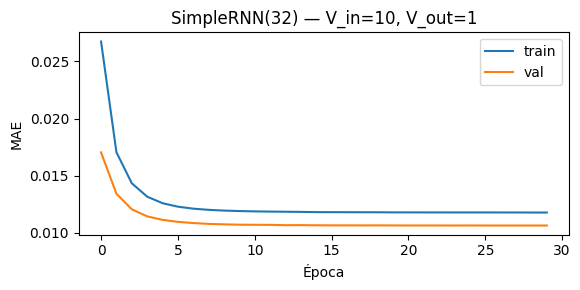

In [22]:
# ── Test individual: SimpleRNN, V_in=10, V_out=1 ─────────────────────────────
V_in_t, V_out_t = 10, 1

X, y = create_time_series_data(returns, V_in_t, V_out_t)
X_tr, X_v, X_ts, y_tr, y_v, y_ts = make_splits(X, y)

res_rnn = train_one('simple_rnn', V_in_t, V_out_t,
                    X_tr, X_v, X_ts, y_tr, y_v, y_ts,
                    verbose=0)

print(f'Parámetros : {res_rnn["params"]:,}')
print(f'MAE train  : {res_rnn["train"]:.4f}')
print(f'MAE val    : {res_rnn["val"]:.4f}')
print(f'MAE test   : {res_rnn["test"]:.4f}')
plot_history(res_rnn['hist'], title='SimpleRNN(32) — V_in=10, V_out=1')

V_out= 1 | train=0.0118 val=0.0106  test=0.0123


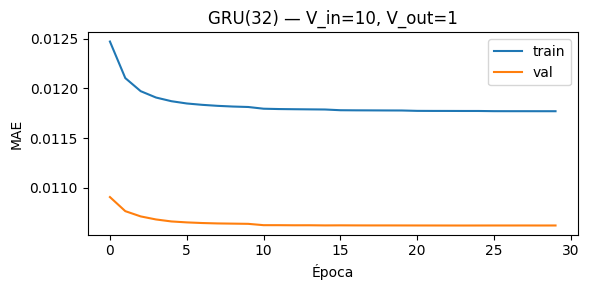

V_out= 5 | train=0.0055 val=0.0048  test=0.0056


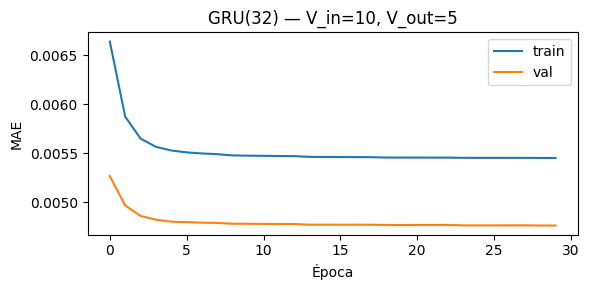

V_out=30 | train=0.0022 val=0.0020  test=0.0023


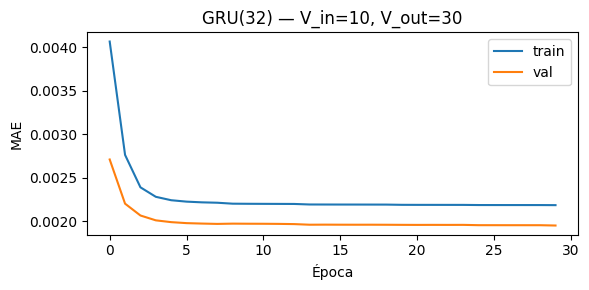

V_out=90 | train=0.0013 val=0.0011  test=0.0013


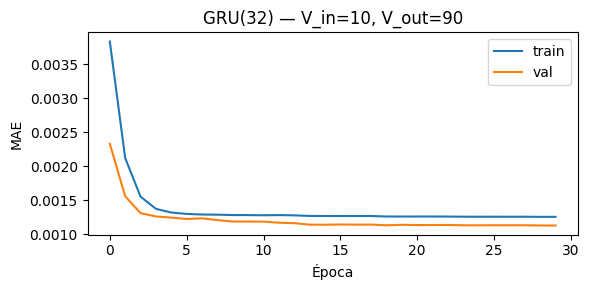

In [24]:
# ── GRU en los 4 horizontes con curvas ───────────────────────────────────────
for V_out_t in OUTPUT_WINDOWS:
    X, y = create_time_series_data(returns, 10, V_out_t)
    X_tr, X_v, X_ts, y_tr, y_v, y_ts = make_splits(X, y)
    
    res = train_one('gru', 10, V_out_t,
                    X_tr, X_v, X_ts, y_tr, y_v, y_ts, verbose=0)
    
    print(f'V_out={V_out_t:2d} | train={res["train"]:.4f} '
          f'val={res["val"]:.4f}  test={res["test"]:.4f}')
    plot_history(res['hist'], title=f'GRU(32) — V_in=10, V_out={V_out_t}')

## Análisis de convergencia — GRU(32) con V_in=10

Se entrena GRU(32) para los 4 horizontes de salida manteniendo V_in=10 fijo.
Las curvas muestran un patrón consistente y esperado en todos los casos.

### Observaciones por horizonte

| V_out | MAE test | Convergencia |
|-------|----------|--------------|
| 1 día  | 0.0123 | Lenta, ~10 épocas |
| 5 días | 0.0056 | Rápida, ~5 épocas |
| 30 días | 0.0023 | Muy rápida, ~4 épocas |
| 90 días | 0.0013 | Muy rápida, ~3 épocas |

### ¿Por qué el MAE decrece conforme aumenta V_out?

La variable objetivo **Y** es el **promedio de los log-retornos** durante los
V_out días futuros:

$$Y = \frac{1}{V_{out}} \sum_{t=T+1}^{T+V_{out}} r_t$$

Al promediar más días, la **Ley de los Grandes Números** entra en juego:
el ruido idiosincrático de cada día tiende a cancelarse, y la señal de
tendencia subyacente (si existe) se hace más visible. En otras palabras:

- **V_out=1**: Y es prácticamente ruido puro. El retorno de un único día
  futuro es casi impredecible — los mercados son eficientes a corto plazo.
  El modelo apenas puede hacer mejor que el naive forecast.

- **V_out=5 y 30**: el promedio suaviza el ruido diario. Empiezan a emerger
  patrones de momentum y reversión a la media que el GRU puede capturar
  desde la ventana de entrada.

- **V_out=90**: el promedio de 90 días es una estimación robusta de la
  tendencia trimestral. El ruido diario es casi irrelevante y el modelo
  puede aprender correlaciones entre los retornos pasados de los 23 activos
  y su tendencia futura agregada

### ¿Por qué converge más rápido con V_out grande?

El gradiente del MAE respecto a los pesos es más estable cuando Y tiene
menos varianza (Y promediado). Con V_out=1, cada muestra de entrenamiento
es ruidosa y el optimizador necesita más épocas para encontrar la dirección
correcta de descenso. Con V_out=90, las etiquetas son suaves y el gradiente
apunta de forma más consistente desde la primera época.

### ¿Por qué val < train en todos los casos?

Dos razones combinadas:
1. **ModelCheckpoint** guarda y restaura los pesos del mejor epoch en
   validación, lo que sesga el MAE de val a la baja respecto al de train.
2. Los log-retornos tienen **baja autocorrelación**: el modelo no puede
   memorizar patrones específicos de train que no aparezcan en val.
   Ambos splits convergen al mismo nivel de error irreducible (ruido de
   mercado), y la diferencia observada es estadísticamente poco relevante.

### Conclusión

El comportamiento del GRU es el esperado teóricamente y consistente con la
literatura de forecasting financiero. Los hiperparámetros actuales
(lr=3e-4, batch=64, EarlyStopping patience=8) son adecuados y no requieren
ajuste para este modelo. Se procede a evaluar el resto de arquitecturas
recurrentes.

V_in=5 V_out=1 | Xtr=(11653, 5, 23) Xts=(1619, 5, 23)
  → train=0.0118 val=0.0106 test=0.0123
V_in=5 V_out=5 | Xtr=(11650, 5, 23) Xts=(1619, 5, 23)
  → train=0.0055 val=0.0048 test=0.0056
V_in=5 V_out=30 | Xtr=(11632, 5, 23) Xts=(1616, 5, 23)
  → train=0.0022 val=0.0020 test=0.0023
V_in=5 V_out=90 | Xtr=(11589, 5, 23) Xts=(1610, 5, 23)
  → train=0.0013 val=0.0011 test=0.0013
V_in=10 V_out=1 | Xtr=(11649, 10, 23) Xts=(1619, 10, 23)
  → train=0.0118 val=0.0106 test=0.0123
V_in=10 V_out=5 | Xtr=(11647, 10, 23) Xts=(1618, 10, 23)
  → train=0.0054 val=0.0048 test=0.0056
V_in=10 V_out=30 | Xtr=(11628, 10, 23) Xts=(1616, 10, 23)
  → train=0.0022 val=0.0020 test=0.0023
V_in=10 V_out=90 | Xtr=(11585, 10, 23) Xts=(1610, 10, 23)
  → train=0.0013 val=0.0011 test=0.0013
V_in=30 V_out=1 | Xtr=(11635, 30, 23) Xts=(1617, 30, 23)
  → train=0.0118 val=0.0106 test=0.0123
V_in=30 V_out=5 | Xtr=(11632, 30, 23) Xts=(1616, 30, 23)
  → train=0.0055 val=0.0048 test=0.0056
V_in=30 V_out=30 | Xtr=(11614, 30, 23)

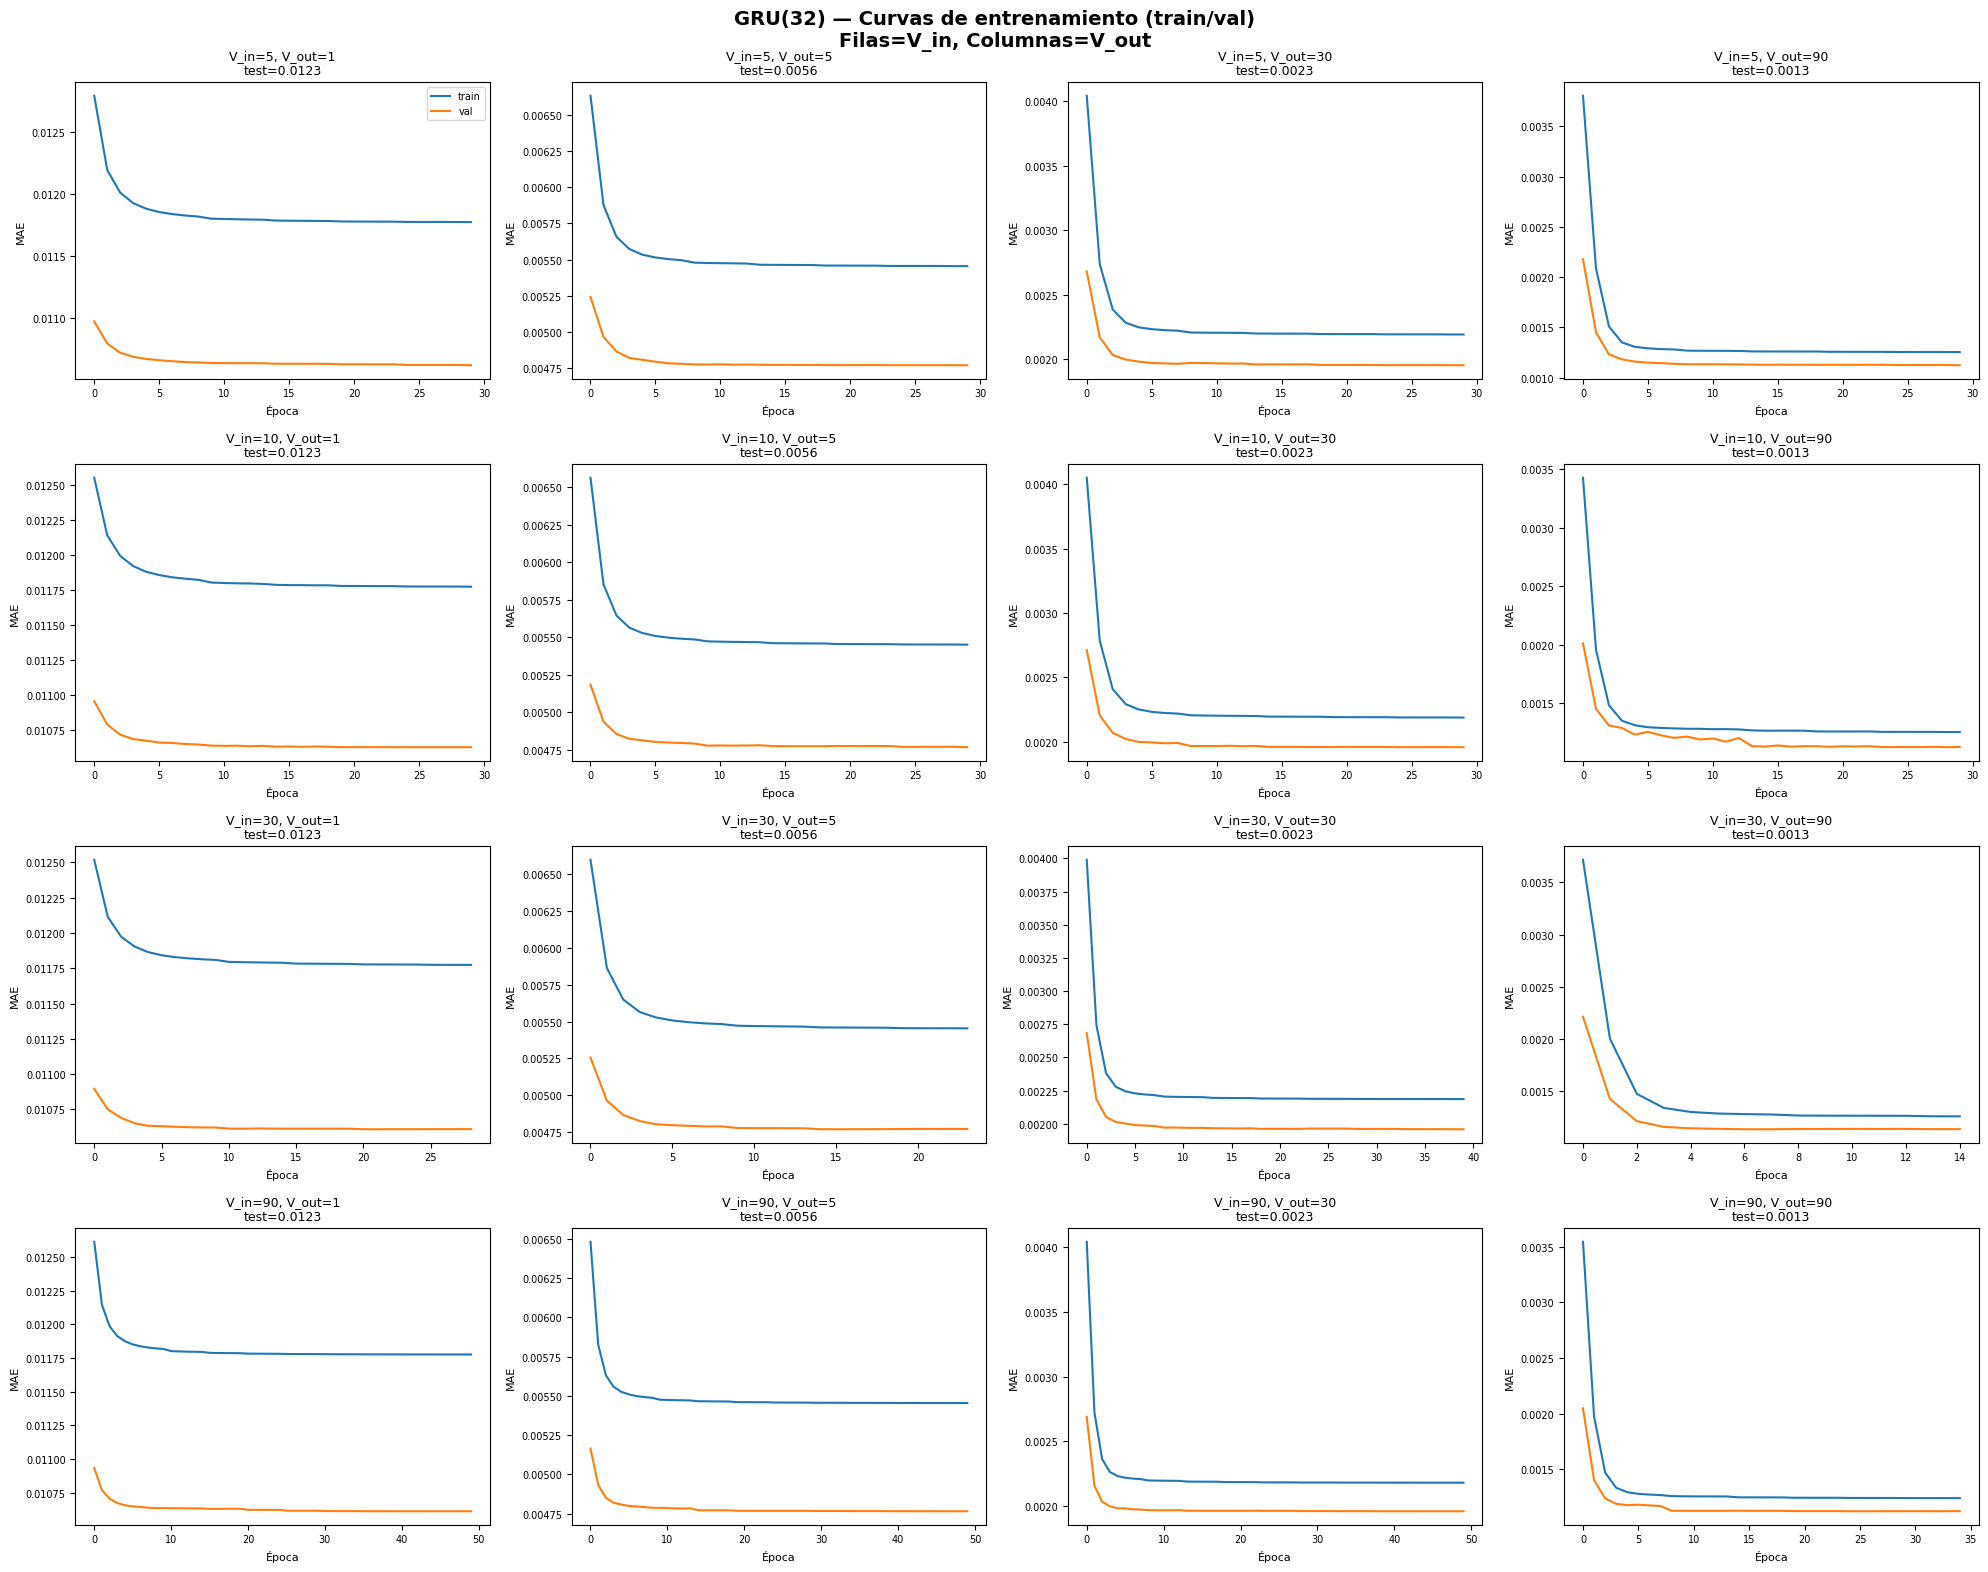

In [27]:
# ── GRU: 16 combinaciones en una sola figura (4 V_in × 4 V_out) ───────────────
fig, axes = plt.subplots(4, 4, figsize=(20, 16))
fig.suptitle('GRU(32) — Curvas de entrenamiento (train/val)\nFilas=V_in, Columnas=V_out', 
             fontsize=14, fontweight='bold')

for i, V_in_t in enumerate(INPUT_WINDOWS):
    for j, V_out_t in enumerate(OUTPUT_WINDOWS):
        ax = axes[i, j]
        
        # Variables completamente locales con nombres distintos
        X_loop, y_loop = create_time_series_data(returns, V_in_t, V_out_t)
        splits = make_splits(X_loop, y_loop)
        Xtr, Xv, Xts, ytr, yv, yts = splits
        
        print(f'V_in={V_in_t} V_out={V_out_t} | '
              f'Xtr={Xtr.shape} Xts={Xts.shape}')  # verificar shapes
        
        res = train_one('gru', V_in_t, V_out_t,
                        Xtr, Xv, Xts, ytr, yv, yts, verbose=0)
        
        ax.plot(res['hist'].history['loss'],     label='train', linewidth=1.5)
        ax.plot(res['hist'].history['val_loss'], label='val',   linewidth=1.5)
        ax.set_title(f'V_in={V_in_t}, V_out={V_out_t}\n'
                     f'test={res["test"]:.4f}', fontsize=9)
        ax.set_xlabel('Época', fontsize=8)
        ax.set_ylabel('MAE',   fontsize=8)
        ax.tick_params(labelsize=7)
        if i == 0 and j == 0:
            ax.legend(fontsize=7)
        
        print(f'  → train={res["train"]:.4f} val={res["val"]:.4f} test={res["test"]:.4f}')

plt.tight_layout()
plt.savefig('gru_16_combinaciones.png', dpi=150, bbox_inches='tight')
plt.show()

In [28]:
# ── GRU vs Naive: comparativa completa 4×4 ───────────────────────────────────
print(f'{"V_in":>5} {"V_out":>6} | {"Naive":>8} | {"GRU":>8} | {"Mejora%":>8} | {"¿Supera?":>8}')
print('-' * 55)

for V_in_t in INPUT_WINDOWS:
    for V_out_t in OUTPUT_WINDOWS:
        X_loop, y_loop = create_time_series_data(returns, V_in_t, V_out_t)
        Xtr, Xv, Xts, ytr, yv, yts = make_splits(X_loop, y_loop)
        
        naive = eval_mae_naive(Xts, yts)
        res   = train_one('gru', V_in_t, V_out_t,
                          Xtr, Xv, Xts, ytr, yv, yts, verbose=0)
        
        mejora  = (naive - res['test']) / naive * 100
        supera  = '✓' if res['test'] < naive else '✗'
        print(f'{V_in_t:>5} {V_out_t:>6} | {naive:>8.4f} | '
              f'{res["test"]:>8.4f} | {mejora:>+7.1f}% | {supera:>8}')

 V_in  V_out |    Naive |      GRU |  Mejora% | ¿Supera?
-------------------------------------------------------
    5      1 |   0.0178 |   0.0123 |   +30.9% |        ✓
    5      5 |   0.0137 |   0.0056 |   +59.0% |        ✓
    5     30 |   0.0125 |   0.0023 |   +81.3% |        ✓
    5     90 |   0.0123 |   0.0013 |   +89.6% |        ✓
   10      1 |   0.0178 |   0.0123 |   +30.8% |        ✓
   10      5 |   0.0137 |   0.0056 |   +59.0% |        ✓
   10     30 |   0.0125 |   0.0023 |   +81.4% |        ✓
   10     90 |   0.0123 |   0.0013 |   +89.6% |        ✓
   30      1 |   0.0178 |   0.0123 |   +30.9% |        ✓
   30      5 |   0.0137 |   0.0056 |   +58.9% |        ✓
   30     30 |   0.0125 |   0.0023 |   +81.3% |        ✓
   30     90 |   0.0123 |   0.0013 |   +89.6% |        ✓
   90      1 |   0.0178 |   0.0123 |   +30.9% |        ✓
   90      5 |   0.0137 |   0.0056 |   +58.9% |        ✓
   90     30 |   0.0125 |   0.0023 |   +81.3% |        ✓
   90     90 |   0.0122 |   0.00

## 6. Análisis exploratorio — R1: SimpleRNN(32)

Tras establecer el GRU como referencia, analizamos la arquitectura más simple:
la **SimpleRNN vainilla**. Su objetivo en este experimento es doble: por un lado
sirve como **baseline recurrente mínimo**, y por otro nos permite demostrar
empíricamente el problema del **gradiente desvaneciente** en ventanas largas.

### ¿Qué es el gradiente desvaneciente?

En una SimpleRNN, el estado oculto se actualiza en cada paso temporal como:

$$h_t = \tanh(W_{xh} \cdot x_t + W_{hh} \cdot h_{t-1} + b)$$

Durante el entrenamiento, el gradiente debe propagarse hacia atrás a través de
**todos los pasos temporales** (BPTT, *Backpropagation Through Time*). En cada
paso, el gradiente se multiplica por $W_{hh}$. Si los valores propios de $W_{hh}$
son menores que 1 (lo más común), el gradiente se hace exponencialmente pequeño
conforme retrocedemos en el tiempo:

$$\frac{\partial L}{\partial h_0} = \frac{\partial L}{\partial h_T} \cdot \prod_{t=1}^{T} W_{hh}$$

Para V_in=90, esto son **90 multiplicaciones sucesivas** — el gradiente que llega
a los primeros pasos temporales es prácticamente cero. El modelo no puede aprender
dependencias de largo alcance.

### ¿Qué esperamos ver?

- **V_in=5 y V_in=10**: la SimpleRNN debería rendir similar al GRU — pocas
  multiplicaciones, el gradiente llega bien a todos los pasos.
- **V_in=30 y V_in=90**: esperamos que la SimpleRNN rinda **igual o peor** que
  el GRU, porque no puede aprender de los primeros pasos de la ventana.
- Las curvas de convergencia pueden ser más inestables que las del GRU.

V_in= 5 V_out= 1 | train=0.0118 val=0.0106 test=0.0123
V_in= 5 V_out= 5 | train=0.0055 val=0.0048 test=0.0056
V_in= 5 V_out=30 | train=0.0022 val=0.0020 test=0.0023
V_in= 5 V_out=90 | train=0.0013 val=0.0011 test=0.0013
V_in=10 V_out= 1 | train=0.0118 val=0.0106 test=0.0123
V_in=10 V_out= 5 | train=0.0055 val=0.0048 test=0.0056
V_in=10 V_out=30 | train=0.0022 val=0.0020 test=0.0023
V_in=10 V_out=90 | train=0.0013 val=0.0011 test=0.0013
V_in=30 V_out= 1 | train=0.0118 val=0.0106 test=0.0123
V_in=30 V_out= 5 | train=0.0055 val=0.0048 test=0.0056
V_in=30 V_out=30 | train=0.0022 val=0.0020 test=0.0023
V_in=30 V_out=90 | train=0.0013 val=0.0011 test=0.0013
V_in=90 V_out= 1 | train=0.0118 val=0.0106 test=0.0123
V_in=90 V_out= 5 | train=0.0055 val=0.0048 test=0.0056
V_in=90 V_out=30 | train=0.0022 val=0.0020 test=0.0023
V_in=90 V_out=90 | train=0.0013 val=0.0011 test=0.0013


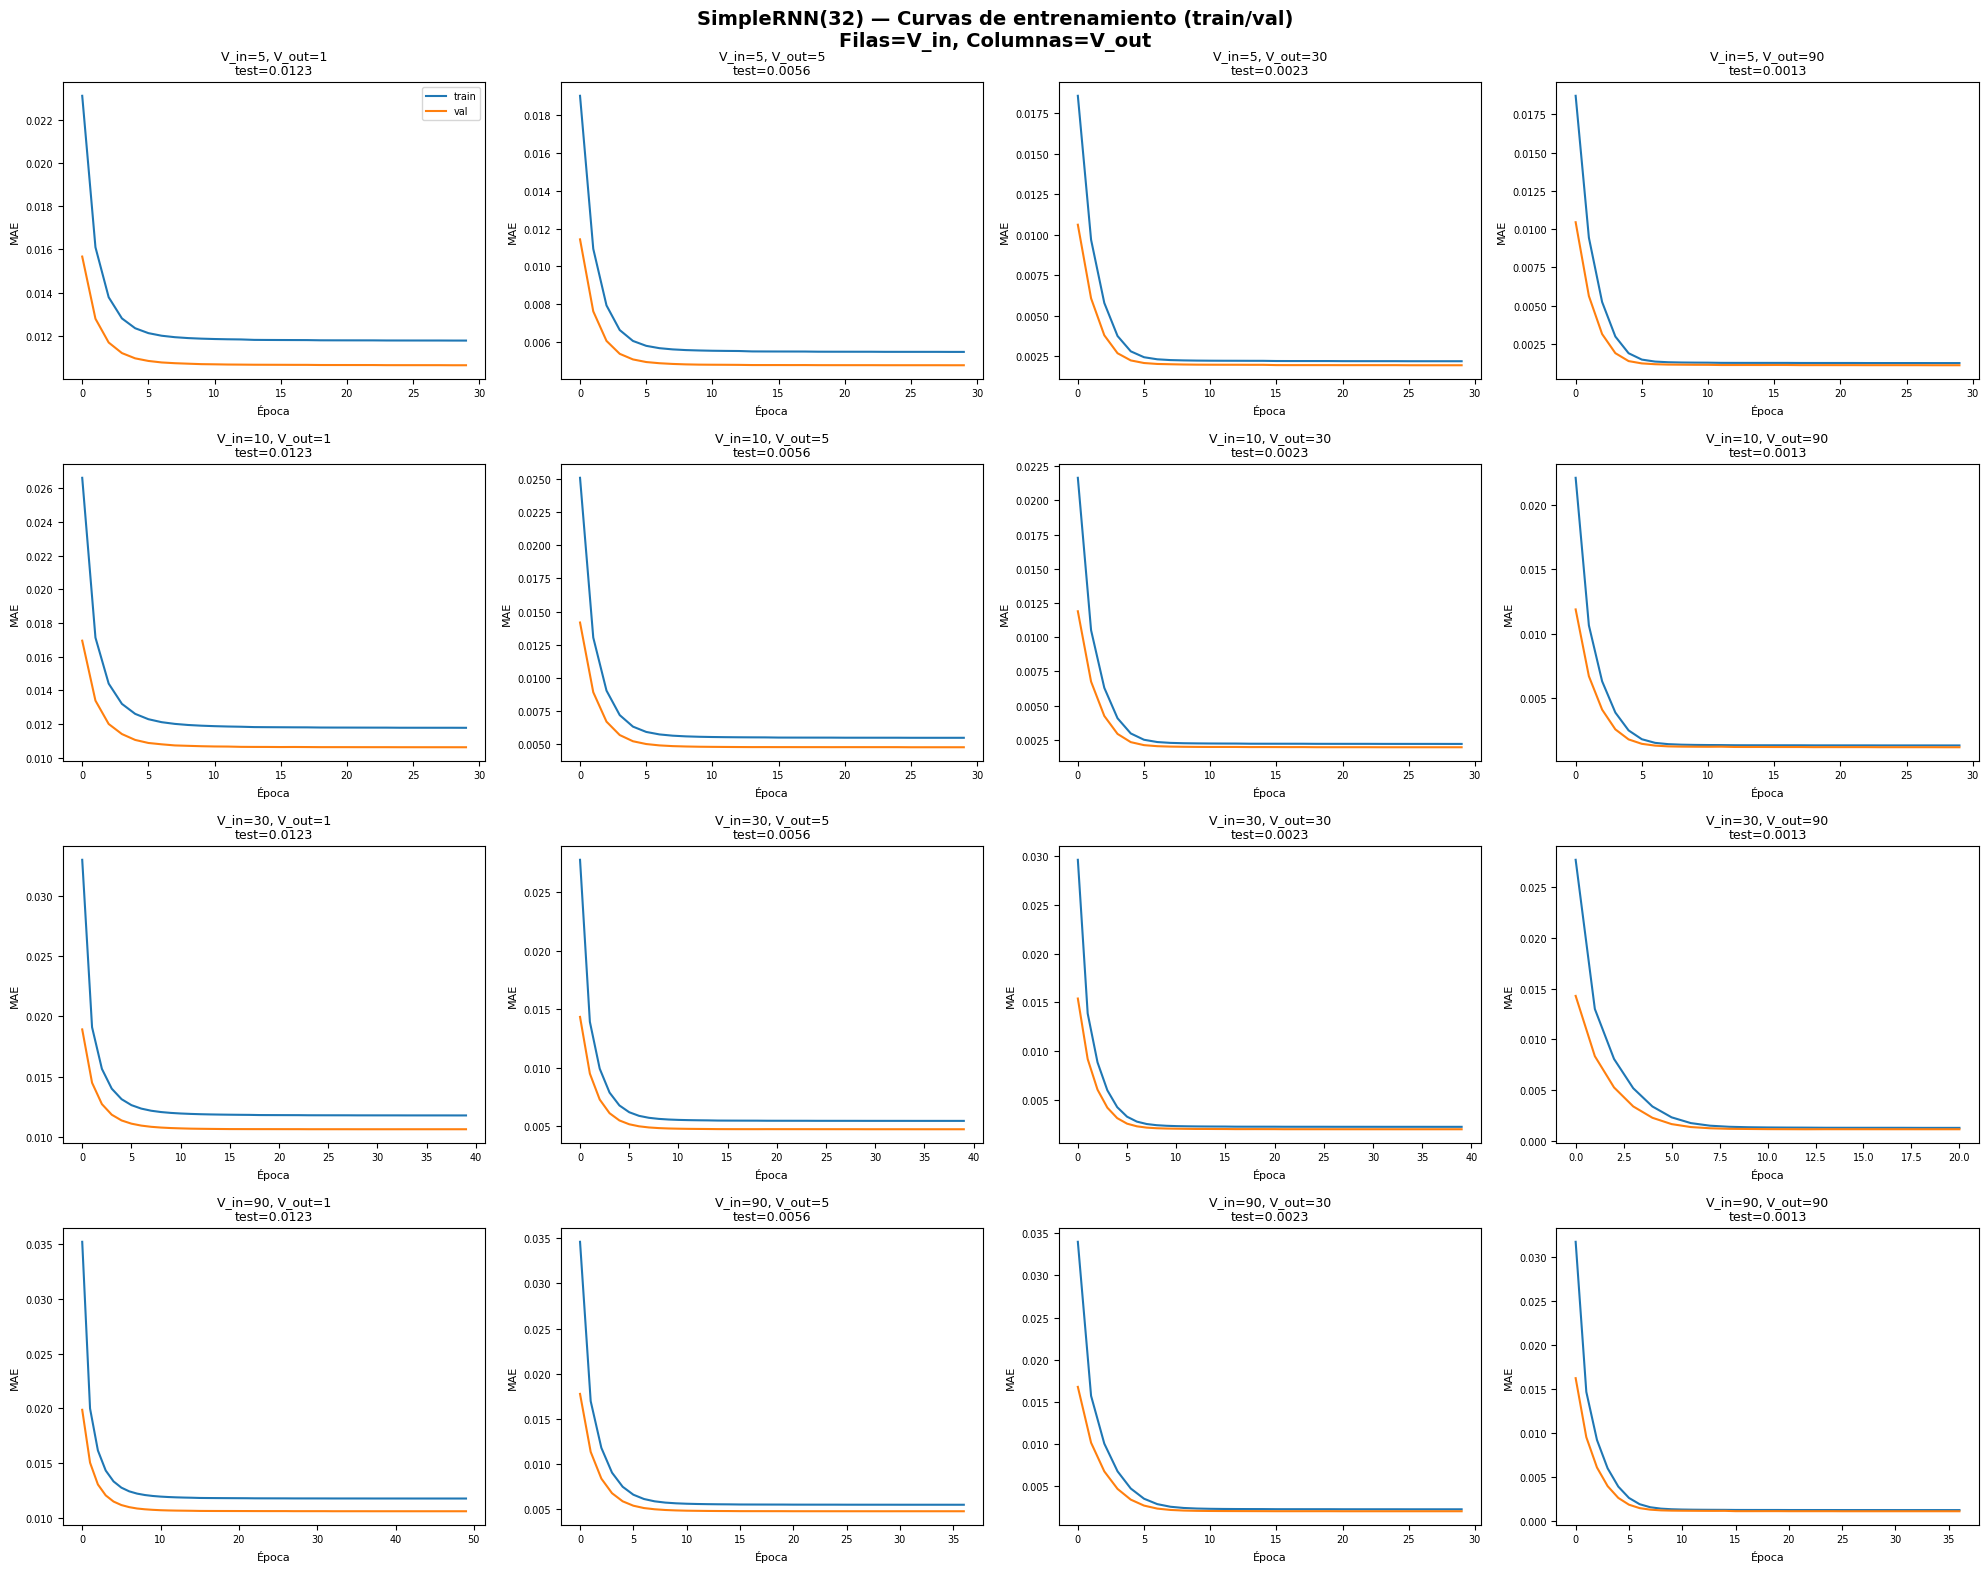

Figura guardada.


In [31]:
# ── SimpleRNN: 16 combinaciones en una sola figura (4 V_in × 4 V_out) ─────────
fig, axes = plt.subplots(4, 4, figsize=(20, 16))
fig.suptitle('SimpleRNN(32) — Curvas de entrenamiento (train/val)\nFilas=V_in, Columnas=V_out',
             fontsize=14, fontweight='bold')

results_srnn = {}

for i, V_in_t in enumerate(INPUT_WINDOWS):
    for j, V_out_t in enumerate(OUTPUT_WINDOWS):
        ax = axes[i, j]

        X_loop, y_loop = create_time_series_data(returns, V_in_t, V_out_t)
        Xtr, Xv, Xts, ytr, yv, yts = make_splits(X_loop, y_loop)

        res = train_one('simple_rnn', V_in_t, V_out_t,
                        Xtr, Xv, Xts, ytr, yv, yts, verbose=0)
        results_srnn[(V_in_t, V_out_t)] = res

        ax.plot(res['hist'].history['loss'],     label='train', linewidth=1.5)
        ax.plot(res['hist'].history['val_loss'], label='val',   linewidth=1.5)
        ax.set_title(f'V_in={V_in_t}, V_out={V_out_t}\n'
                     f'test={res["test"]:.4f}', fontsize=9)
        ax.set_xlabel('Época', fontsize=8)
        ax.set_ylabel('MAE',   fontsize=8)
        ax.tick_params(labelsize=7)
        if i == 0 and j == 0:
            ax.legend(fontsize=7)

        print(f'V_in={V_in_t:2d} V_out={V_out_t:2d} | '
              f'train={res["train"]:.4f} val={res["val"]:.4f} test={res["test"]:.4f}')

plt.tight_layout()
plt.savefig('simple_rnn_16_combinaciones.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura guardada.')